# Loading Data

In [120]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split , TimeSeriesSplit
from sklearn.linear_model import Ridge , Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error , mean_absolute_error , r2_score
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA

# Load the dataset
data = pd.read_csv(r"C:\Users\hana\Downloads\Gold_Data_Final_Cleaned.csv")
data.head()

,Date,Gold_Price,Silver,Platinum,Copper,SP500,DXY,JPY_USD,GBP_USD,CNY_USD,...,Volatility_7d,Volatility_30d,Momentum_14d,Gold_Silver_Ratio,Gold_Oil_Ratio,Target_NextDay,Gold_VIX_interaction,Rolling_std_7,Price_diff,Month_cos
0,2004-11-18 00:00:00,442.600006,7.549,862.700012,1.4750,1183.550049,83.690002,104.300003,1.848292,8.266501,...,0.006093,0.007996,14.100006,58.630285,9.575941,446.799988,5744.947877,3.972704,-2.199982,0.866025
1,2004-11-19 00:00:00,446.799988,7.597,859.700012,1.4820,1170.339966,83.309998,103.080002,1.860084,8.266501,...,0.005935,0.007890,19.500000,58.812687,9.223782,448.799988,6031.799835,4.339352,4.199982,0.866025
2,2004-11-22 00:00:00,448.799988,7.569,855.200012,1.4590,1177.239990,83.190002,103.160004,1.859808,8.266501,...,0.005862,0.007858,28.799988,59.294491,9.226974,447.799988,5820.935962,4.474525,2.000000,0.866025
3,2004-11-23 00:00:00,447.799988,7.553,856.900024,1.4675,1176.939941,82.970001,103.330002,1.868984,8.266501,...,0.006247,0.007103,23.199982,59.287699,9.149980,449.299988,5673.625880,4.308124,-1.000000,0.866025
4,2004-12-08 00:00:00,437.200012,7.102,834.099976,1.3755,1182.810059,81.900002,104.029999,1.937083,8.266501,...,0.014164,0.009493,-5.399994,61.560124,10.424416,435.799988,5766.667978,4.279677,-12.099976,1.000000


In [121]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3400 entries, 0 to 3399
Data columns (total 34 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Date                  3400 non-null   object 
 1   Gold_Price            3400 non-null   float64
 2   Silver                3400 non-null   float64
 3   Platinum              3400 non-null   float64
 4   Copper                3400 non-null   float64
 5   SP500                 3400 non-null   float64
 6   DXY                   3400 non-null   float64
 7   JPY_USD               3400 non-null   float64
 8   GBP_USD               3400 non-null   float64
 9   CNY_USD               3400 non-null   float64
 10  US_2Y_Yield           3400 non-null   float64
 11  TIP_ETF               3400 non-null   float64
 12  Real_Rate_10Y         3400 non-null   float64
 13  PPI                   3400 non-null   float64
 14  Treasury_Spread       3400 non-null   float64
 15  Unemployment         

In [122]:
X = data.drop('Target_NextDay', axis=1).select_dtypes(include=np.number).dropna()
y = data['Target_NextDay'].dropna()
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42 , shuffle=False)

print(f"Train: {X_train.shape} {y_train.shape}")
print(f"Test: {X_test.shape} {y_test.shape}")

Train: (2720, 32) (2720,)
Test: (680, 32) (680,)


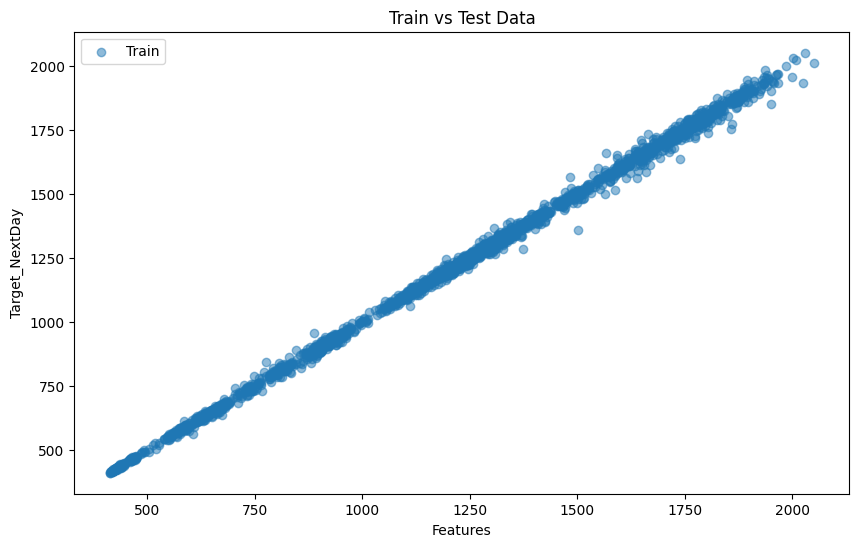

In [123]:
plt.figure(figsize=(10, 6))
plt.scatter(X_train[X_train.columns[0]], y_train, alpha=0.5, label='Train')
plt.xlabel('Features')
plt.ylabel('Target_NextDay')
plt.title('Train vs Test Data')
plt.legend()
plt.show()

In [124]:
pca = PCA(n_components=10)
X_train = pca.fit_transform(X_train)
X_test = pca.transform(X_test)

# lasso model

In [125]:
Lassomodel = Pipeline([
    ('scaler', StandardScaler()),
    ('model', Lasso(alpha=0.01))
])

Lassomodel.fit(X_train, y_train)
lasso_pred = Lassomodel.predict(X_test)
mse_lasso = mean_squared_error(y_test, lasso_pred)
mae_lasso = mean_absolute_error(y_test, lasso_pred)
rmse_lasso = np.sqrt(mse_lasso)   
r2_lasso = r2_score(y_test, lasso_pred)
print(f"Lasso Regression - MSE: {mse_lasso:.4f} ,RMSE: {rmse_lasso:.4f} , MAE: {mae_lasso:.4f}, R2: {r2_lasso:.4f}")

Lasso Regression - MSE: 2184.8194 ,RMSE: 46.7421 , MAE: 26.0041, R2: 0.9973


In [126]:
print("Train R2:", Lassomodel.score(X_train, y_train))
print("Test R2:", Lassomodel.score(X_test, y_test))

Train R2: 0.9986286522304796
Test R2: 0.9973384367752167


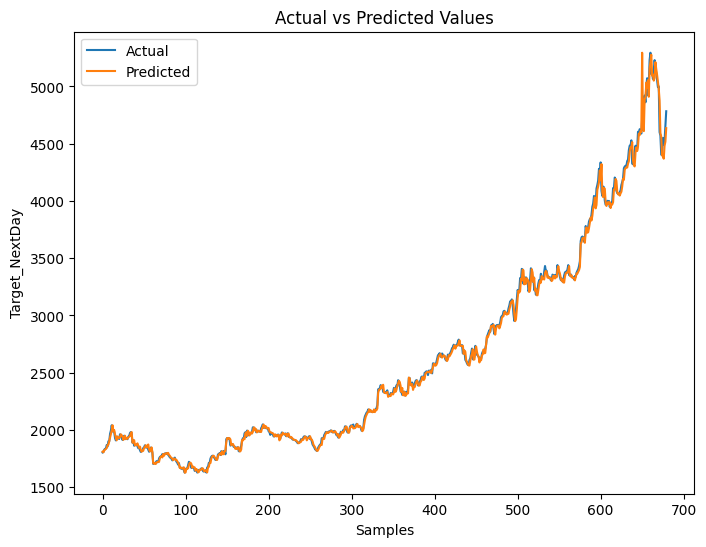

In [127]:
plt.figure(figsize=(8, 6))
plt.plot(y_test.values, label='Actual')
plt.plot(lasso_pred, label='Predicted')     
plt.xlabel('Samples')
plt.ylabel('Target_NextDay')        
plt.title('Actual vs Predicted Values')
plt.legend()
plt.show()

# Ridge Model 

In [128]:
Ridgemodel = Pipeline([
    ('scaler', StandardScaler()),
    ('model', Ridge(alpha=1.0, random_state=42))
])

Ridgemodel.fit(X_train, y_train)
ridge_pred = Ridgemodel.predict(X_test)
mse_ridge = mean_squared_error(y_test, ridge_pred)
mae_ridge = mean_absolute_error(y_test, ridge_pred)
rmse_ridge = np.sqrt(mse_ridge)   
r2_ridge = r2_score(y_test, ridge_pred)
print(f"Ridge Regression - MSE: {mse_ridge:.4f} ,RMSE: {rmse_ridge:.4f} , MAE: {mae_ridge:.4f}, R2: {r2_ridge:.4f}")

Ridge Regression - MSE: 2191.9174 ,RMSE: 46.8179 , MAE: 26.1343, R2: 0.9973


In [129]:
print("Train R2:", Ridgemodel.score(X_train, y_train))
print("Test R2:", Ridgemodel.score(X_test, y_test))

Train R2: 0.9986285238595521
Test R2: 0.9973297899326056


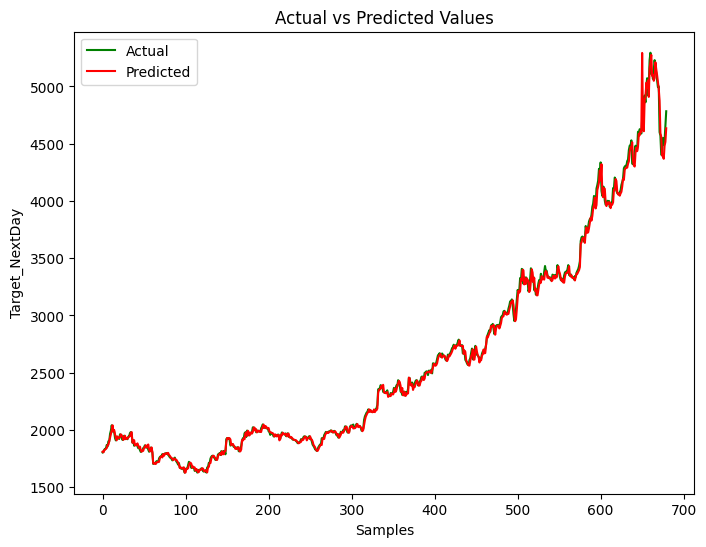

In [130]:
plt.figure(figsize=(8, 6))
plt.plot(y_test.values, label='Actual' , color='green')
plt.plot(ridge_pred, label='Predicted' , color='red')     
plt.xlabel('Samples')
plt.ylabel('Target_NextDay')        
plt.title('Actual vs Predicted Values')
plt.legend()
plt.show()

# Results

In [131]:
result = {'Ridge': (mse_ridge, rmse_ridge, mae_ridge, r2_ridge), 'Lasso': (mse_lasso, rmse_lasso, mae_lasso, r2_lasso)}
results_df = pd.DataFrame(result, index=['MSE', 'RMSE', 'MAE', 'R2'])
print(results_df)

            Ridge        Lasso
MSE   2191.917368  2184.819363
RMSE    46.817917    46.742051
MAE     26.134315    26.004138
R2       0.997330     0.997338


In [132]:
tscv = TimeSeriesSplit(n_splits=5)
models = {'Ridge': Ridge(alpha=1.0, random_state=42), 'Lasso': Lasso(alpha=0.01)}
cv_results = {}

for name, model in models.items():
    print(f"\n{name} Results:")
    scores = []
    for train_idx, test_idx in tscv.split(X):

        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        scaler = StandardScaler()
        X_train = scaler.fit_transform(X_train)
        X_test = scaler.transform(X_test)

        model.fit(X_train, y_train)

        y_pred = model.predict(X_test)
        scores.append(r2_score(y_test, y_pred))
    cv_results[name] = np.mean(scores)
    print("Average R2:", np.mean(scores))


Ridge Results:
Average R2: 0.9391098716178435

Lasso Results:
Average R2: 0.9692148091132374


# Predict Samples 

In [133]:
sample_X = X.iloc[:10]
sample_y = y.iloc[:10]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

sample_X_scaled = X_scaled[:10]

model = Lasso() 
model.fit(X_scaled, y)

y_pred = model.predict(sample_X_scaled)

results = pd.DataFrame({
    "Actual": sample_y.values,
    "Predicted": y_pred
})

print(results)

       Actual   Predicted
0  446.799988  444.250030
1  448.799988  447.760421
2  447.799988  449.946344
3  449.299988  449.260415
4  435.799988  440.264344
5  433.899994  438.128424
6  438.899994  436.465195
7  435.899994  440.793436
8  440.799988  438.609983
9  442.399994  443.219902


# Final Report

In [134]:
print("="*70)
print("              FINAL MODEL COMPARISON REPORT")
print("="*70)

print(f"{'Model':<12} {'Test R²':<12} {'Test MAE':<12} {'Test RMSE':<12} {'CV R²':<12}")
print("-"*70)

models = ['Ridge', 'Lasso']

mae_vals = [mae_ridge, mae_lasso]
rmse_vals = [rmse_ridge, rmse_lasso]
r2_vals = [r2_ridge, r2_lasso]

for i, name in enumerate(models):
    cv = cv_results.get(name, 'N/A')

    print(f"{name:<12} {r2_vals[i]:<12.4f} {mae_vals[i]:<12.1f} {rmse_vals[i]:<12.1f} {str(cv):<12}")

print("\n" + "-"*70)

# 🏆 Best model based on CV
best_model = max(cv_results, key=cv_results.get)

print(f"🏆 WINNER: {best_model} Regression")

if best_model == "Lasso":
    print(f"   MAE: ±{mae_lasso:.1f} | R²: {r2_lasso:.4f}")
elif best_model == "Ridge":
    print(f"   MAE: ±{mae_ridge:.1f} | R²: {r2_ridge:.4f}")

print("\n INSIGHTS:")
print("- Time Series validation used (TimeSeriesSplit)")
print("- Models evaluated on chronological splits to avoid leakage")
print("- Linear models outperform tree-based models in this dataset")
print("- Lasso helps with feature selection and reduces noise")
print("- Ridge provides stable but slightly weaker generalization")

print("\n CONCLUSION:")
print("- Best performing model depends on CV score")
print(f"- Selected model: {best_model}")
print("- Dataset shows strong linear temporal relationship")
print("="*70)

              FINAL MODEL COMPARISON REPORT
Model        Test R²      Test MAE     Test RMSE    CV R²       
----------------------------------------------------------------------
Ridge        0.9973       26.1         46.8         0.9391098716178435
Lasso        0.9973       26.0         46.7         0.9692148091132374

----------------------------------------------------------------------
🏆 WINNER: Lasso Regression
   MAE: ±26.0 | R²: 0.9973

 INSIGHTS:
- Time Series validation used (TimeSeriesSplit)
- Models evaluated on chronological splits to avoid leakage
- Linear models outperform tree-based models in this dataset
- Lasso helps with feature selection and reduces noise
- Ridge provides stable but slightly weaker generalization

 CONCLUSION:
- Best performing model depends on CV score
- Selected model: Lasso
- Dataset shows strong linear temporal relationship


In [135]:
import joblib

joblib.dump(Ridgemodel, "ridge_model.pkl")
joblib.dump(Lassomodel, "lasso_model.pkl")
joblib.dump(scaler, "scaler.pkl")
joblib.dump(pca, "pca_transformer.pkl")


['pca_transformer.pkl']

In [136]:
import os 
print(os.getcwd())

c:\Users\hana\AppData\Local\Packages\5319275A.WhatsAppDesktop_cv1g1gvanyjgm\LocalState\sessions\CB02E89CC62A7BB9D6A8C31B5588D0AEBD65B648\transfers\2026-16
